In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_7 = pd.read_csv("df_7.csv")

date_cols = ["review_date", "order_date", "ship_date", "delivery_date"]

for col in date_cols:
    df_7[col] = pd.to_datetime(df_7[col], errors="coerce")

# Delivery time
df_7["ship_delay_days"] = (df_7["ship_date"] - df_7["order_date"]).dt.days
df_7["delivery_days"] = (df_7["delivery_date"] - df_7["order_date"]).dt.days
df_7["shipping_duration_days"] = (df_7["delivery_date"] - df_7["ship_date"]).dt.days

# Review delay: khách review sau bao lâu kể từ khi nhận hàng
df_7["review_delay_days"] = (df_7["review_date"] - df_7["delivery_date"]).dt.days

# Low rating flag
df_7["low_rating"] = (df_7["rating"] <= 3).astype(int)
df_7["high_rating"] = (df_7["rating"] >= 4).astype(int)

# Price and margin
df_7["profit_margin"] = df_7["price"] - df_7["cogs"]
df_7["margin_rate"] = df_7["profit_margin"] / df_7["price"]

# Price tier
df_7["price_tier"] = pd.qcut(
    df_7["price"],
    q=4,
    labels=["Low price", "Mid-low price", "Mid-high price", "High price"],
    duplicates="drop"
)

# Delivery speed group
df_7["delivery_speed"] = pd.cut(
    df_7["delivery_days"],
    bins=[-1, 3, 5, 7, np.inf],
    labels=["Fast: 0-3 days", "Normal: 4-5 days", "Slow: 6-7 days", "Very slow: 8+ days"]
)

# Check
df_7[[
    "review_id", "order_id", "product_id", "rating",
    "delivery_days", "review_delay_days",
    "category", "segment", "price", "price_tier"
]].head()

,review_id,order_id,product_id,rating,delivery_days,review_delay_days,category,segment,price,price_tier
0,REV-0000001,1,2400,5,7,13,GenZ,Trendy,1109.261061,Low price
1,REV-0000002,3,396,5,3,27,Streetwear,Balanced,11028.428695,High price
2,REV-0000003,10,1431,5,7,10,Outdoor,Activewear,4093.740000,Mid-low price
3,REV-0000005,16,1668,5,7,24,Streetwear,Standard,5164.740000,Mid-high price
4,REV-0000006,17,2352,4,6,6,Streetwear,Performance,4441.323020,Mid-low price


In [6]:
rating_dist = df_7["rating"].value_counts().sort_index().reset_index()
rating_dist.columns = ["rating", "count"]
rating_dist["percentage"] = rating_dist["count"] / rating_dist["count"].sum() * 100

rating_dist

,rating,count,percentage
0,1,5772,5.083178
1,2,9095,8.009617
2,3,17016,14.985337
3,4,36412,32.066648
4,5,45256,39.855219


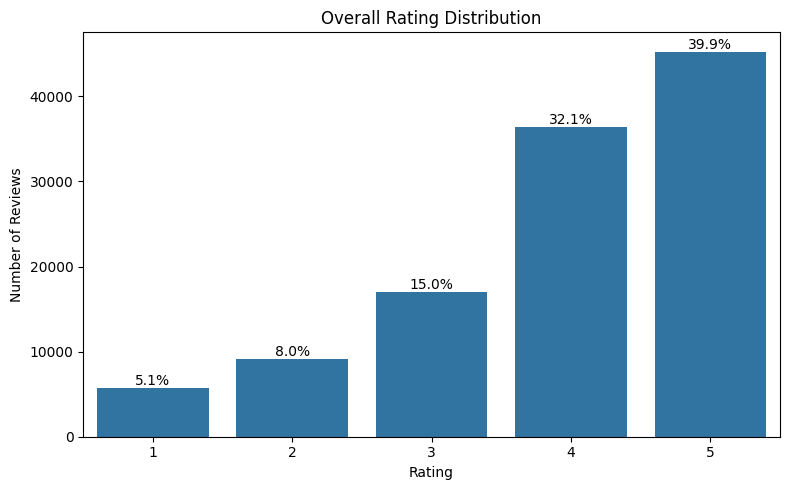

In [7]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=rating_dist,
    x="rating",
    y="count"
)

plt.title("Overall Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

for i, row in rating_dist.iterrows():
    plt.text(
        i,
        row["count"],
        f"{row['percentage']:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [36]:
delivery_rating = df_7.groupby("delivery_days").agg(
    avg_rating=("rating", "mean"),
    low_rating_rate=("low_rating", "mean"),
    num_reviews=("review_id", "count")
).reset_index()

# Loại các nhóm quá ít review để tránh nhiễu
delivery_rating = delivery_rating[delivery_rating["num_reviews"] >= 30]

delivery_rating

,delivery_days,avg_rating,low_rating_rate,num_reviews
0,2,3.948755,0.278184,4781
1,3,3.944491,0.278600,9458
2,4,3.937106,0.279661,14278
3,5,3.934042,0.282151,18724
4,6,3.954651,0.273891,18898
5,7,3.920390,0.285445,19093
6,8,3.939924,0.280498,14132
7,9,3.925773,0.281385,9471
8,10,3.907973,0.294105,4716


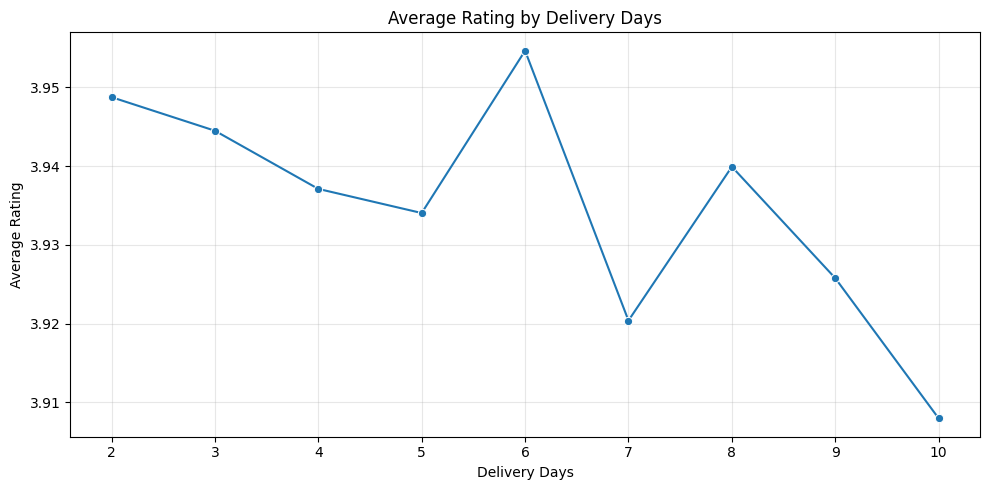

In [9]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=delivery_rating,
    x="delivery_days",
    y="avg_rating",
    marker="o"
)

plt.title("Average Rating by Delivery Days")
plt.xlabel("Delivery Days")
plt.ylabel("Average Rating")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

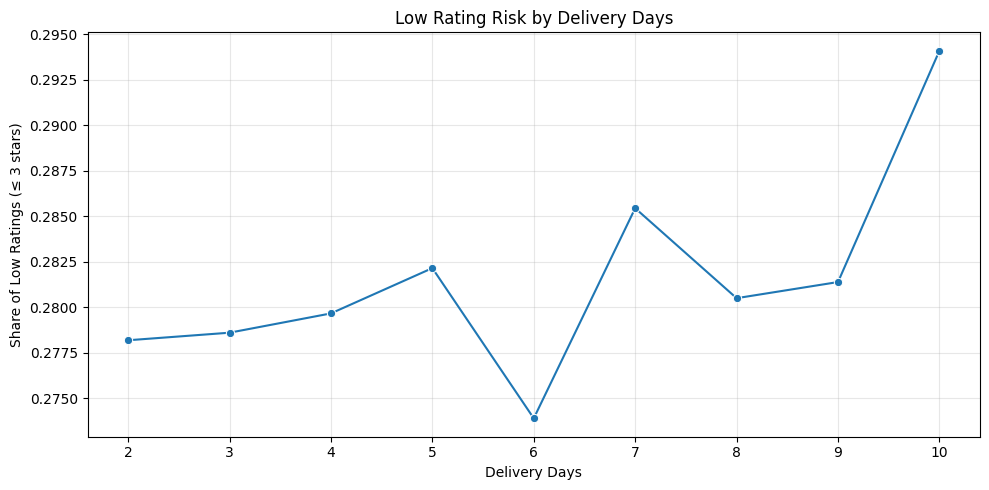

In [10]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=delivery_rating,
    x="delivery_days",
    y="low_rating_rate",
    marker="o"
)

plt.title("Low Rating Risk by Delivery Days")
plt.xlabel("Delivery Days")
plt.ylabel("Share of Low Ratings (≤ 3 stars)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
corr_delivery_rating = df_7[["delivery_days", "rating"]].corr().iloc[0, 1]
corr_delivery_low = df_7[["delivery_days", "low_rating"]].corr().iloc[0, 1]

print(f"Correlation between delivery days and rating: {corr_delivery_rating:.4f}")
print(f"Correlation between delivery days and low rating risk: {corr_delivery_low:.4f}")

Correlation between delivery days and rating: -0.0056
Correlation between delivery days and low rating risk: 0.0045


In [13]:
delivery_speed_perf = df_7.groupby("delivery_speed", observed=True).agg(
    avg_rating=("rating", "mean"),
    low_rating_rate=("low_rating", "mean"),
    num_reviews=("review_id", "count")
).reset_index()

delivery_speed_perf["low_rating_rate_pct"] = delivery_speed_perf["low_rating_rate"] * 100

delivery_speed_perf

,delivery_speed,avg_rating,low_rating_rate,num_reviews,low_rating_rate_pct
0,Fast: 0-3 days,3.945923,0.278461,14239,27.846057
1,Normal: 4-5 days,3.935368,0.281074,33002,28.107387
2,Slow: 6-7 days,3.937433,0.279698,37991,27.969782
3,Very slow: 8+ days,3.929870,0.283061,28319,28.306084


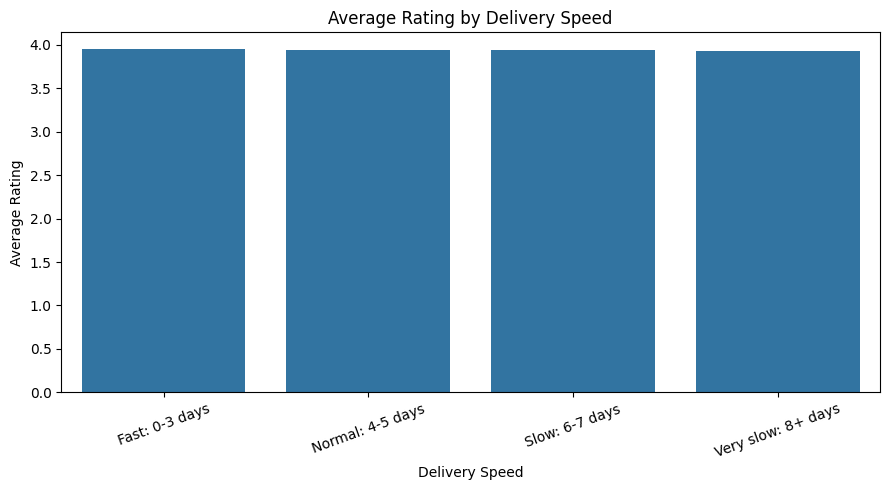

In [14]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=delivery_speed_perf,
    x="delivery_speed",
    y="avg_rating"
)

plt.title("Average Rating by Delivery Speed")
plt.xlabel("Delivery Speed")
plt.ylabel("Average Rating")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [15]:
category_rating = df_7.groupby("category").agg(
    avg_rating=("rating", "mean"),
    low_rating_rate=("low_rating", "mean"),
    num_reviews=("review_id", "count"),
    avg_delivery_days=("delivery_days", "mean"),
    avg_price=("price", "mean")
).reset_index()

category_rating["low_rating_rate_pct"] = category_rating["low_rating_rate"] * 100

category_rating = category_rating.sort_values("avg_rating")

category_rating

,category,avg_rating,low_rating_rate,num_reviews,avg_delivery_days,avg_price,low_rating_rate_pct
1,GenZ,3.922825,0.287465,5792,6.016747,2170.329418,28.746547
0,Casual,3.923219,0.281794,3790,5.960158,4515.759388,28.179420
2,Outdoor,3.933891,0.283388,41265,5.990331,2280.148007,28.338786
3,Streetwear,3.939398,0.278387,62704,6.004928,8018.781631,27.838734


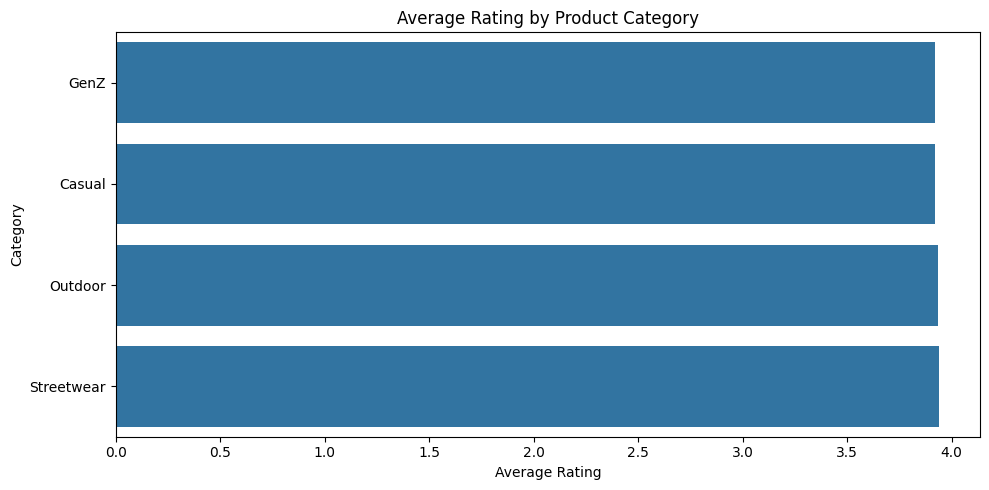

In [16]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=category_rating,
    x="avg_rating",
    y="category"
)

plt.title("Average Rating by Product Category")
plt.xlabel("Average Rating")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [17]:
segment_rating = df_7.groupby("segment").agg(
    avg_rating=("rating", "mean"),
    low_rating_rate=("low_rating", "mean"),
    num_reviews=("review_id", "count"),
    avg_delivery_days=("delivery_days", "mean"),
    avg_price=("price", "mean")
).reset_index()

segment_rating["low_rating_rate_pct"] = segment_rating["low_rating_rate"] * 100
segment_rating = segment_rating.sort_values("avg_rating")

segment_rating

,segment,avg_rating,low_rating_rate,num_reviews,avg_delivery_days,avg_price,low_rating_rate_pct
7,Trendy,3.922825,0.287465,5792,6.016747,2170.329418,28.746547
6,Standard,3.927358,0.289397,1707,6.086702,5240.960075,28.939660
1,All-weather,3.927487,0.282181,3558,5.959528,4451.879835,28.218100
0,Activewear,3.929863,0.285055,36600,5.992787,2114.054297,28.505464
2,Balanced,3.933057,0.280344,16387,6.015866,11969.036879,28.034418
4,Performance,3.937205,0.277076,15447,6.013595,5919.847063,27.707645
3,Everyday,3.944827,0.277338,29163,5.989404,7073.445107,27.733772
5,Premium,3.960384,0.270574,4897,5.971003,3673.853349,27.057382


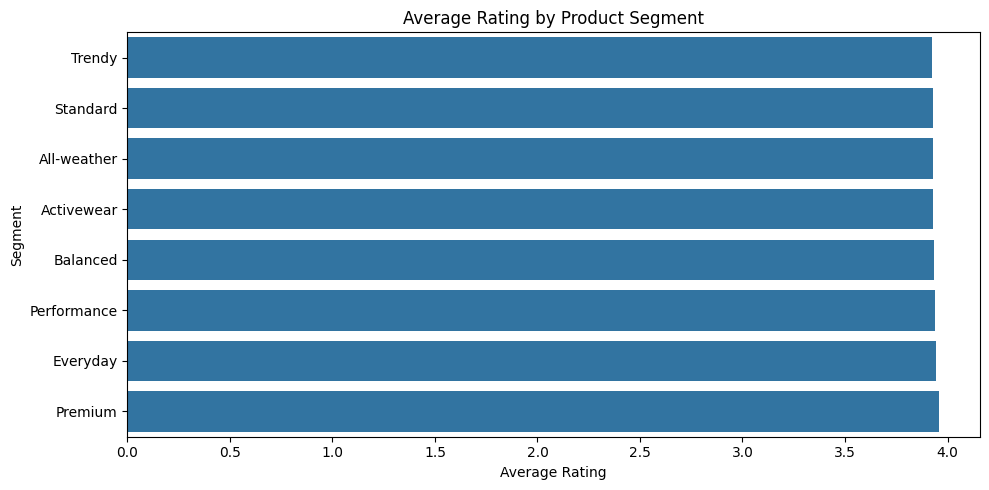

In [18]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=segment_rating,
    x="avg_rating",
    y="segment"
)

plt.title("Average Rating by Product Segment")
plt.xlabel("Average Rating")
plt.ylabel("Segment")
plt.tight_layout()
plt.show()

In [19]:
source_rating = df_7.groupby("order_source").agg(
    avg_rating=("rating", "mean"),
    low_rating_rate=("low_rating", "mean"),
    num_reviews=("review_id", "count"),
    avg_delivery_days=("delivery_days", "mean")
).reset_index()

source_rating["low_rating_rate_pct"] = source_rating["low_rating_rate"] * 100
source_rating = source_rating.sort_values("avg_rating")

source_rating

,order_source,avg_rating,low_rating_rate,num_reviews,avg_delivery_days,low_rating_rate_pct
0,direct,3.926384,0.283077,9047,6.038355,28.307726
5,social_media,3.926912,0.283695,22644,6.017488,28.369546
3,paid_search,3.933934,0.279520,24975,6.007047,27.951952
4,referral,3.934181,0.278395,11243,5.967357,27.839545
2,organic_search,3.942986,0.280365,31887,6.001568,28.036504
1,email_campaign,3.946419,0.279680,13755,5.945765,27.968012


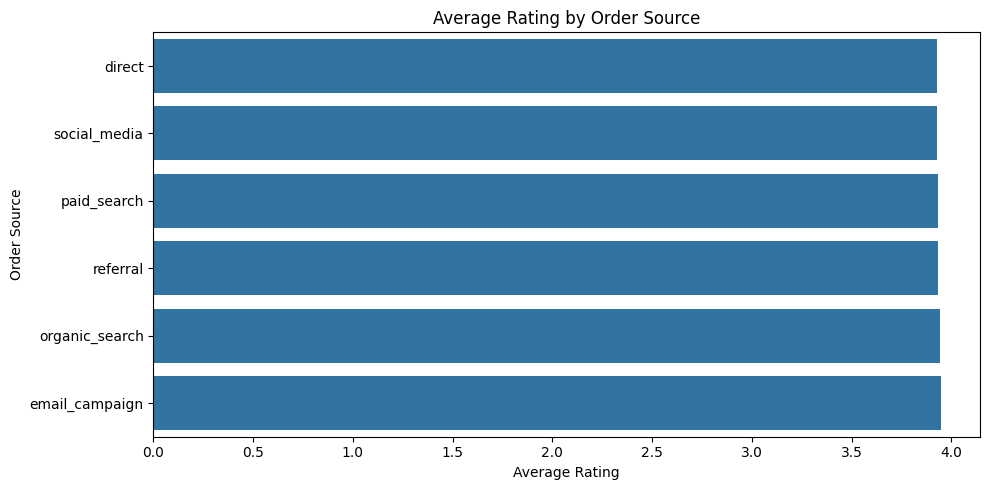

In [21]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=source_rating,
    x="avg_rating",
    y="order_source"
)

plt.title("Average Rating by Order Source")
plt.xlabel("Average Rating")
plt.ylabel("Order Source")
plt.tight_layout()
plt.show()

In [23]:
device_rating = df_7.groupby("device_type").agg(
    avg_rating=("rating", "mean"),
    low_rating_rate=("low_rating", "mean"),
    num_reviews=("review_id", "count"),
    avg_delivery_days=("delivery_days", "mean")
).reset_index()

device_rating["low_rating_rate_pct"] = device_rating["low_rating_rate"] * 100

device_rating

,device_type,avg_rating,low_rating_rate,num_reviews,avg_delivery_days,low_rating_rate_pct
0,desktop,3.942727,0.279200,45222,5.996971,27.920039
1,mobile,3.934418,0.280606,51371,5.998073,28.060579
2,tablet,3.922927,0.285529,16958,6.005425,28.552895


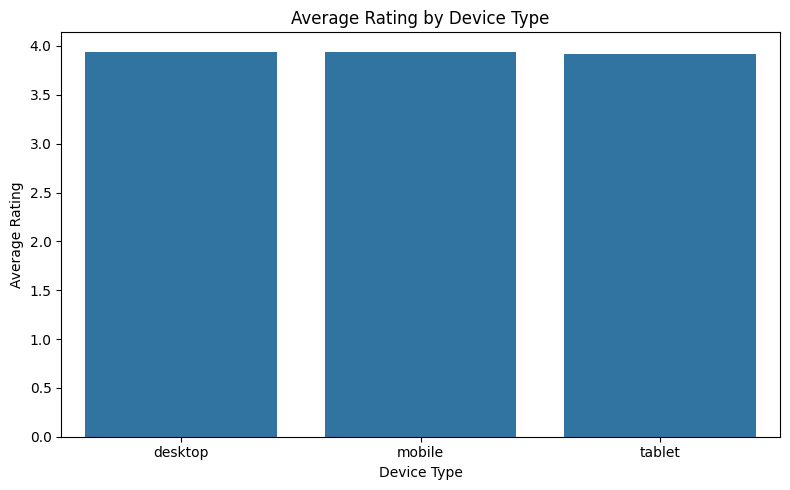

In [24]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=device_rating,
    x="device_type",
    y="avg_rating"
)

plt.title("Average Rating by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.show()

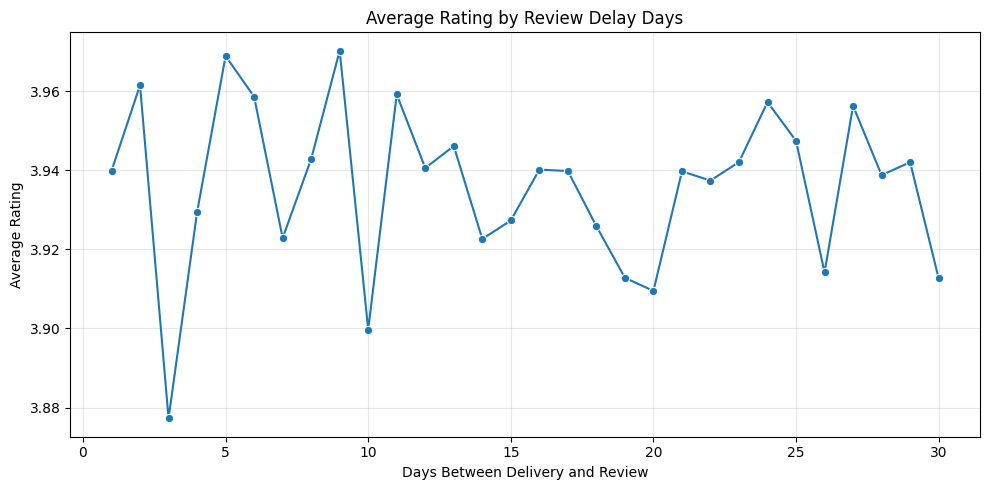

In [25]:
review_delay_rating = df_7.groupby("review_delay_days").agg(
    avg_rating=("rating", "mean"),
    low_rating_rate=("low_rating", "mean"),
    num_reviews=("review_id", "count")
).reset_index()

review_delay_rating = review_delay_rating[
    (review_delay_rating["review_delay_days"] >= 0) &
    (review_delay_rating["num_reviews"] >= 30)
]

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=review_delay_rating,
    x="review_delay_days",
    y="avg_rating",
    marker="o"
)

plt.title("Average Rating by Review Delay Days")
plt.xlabel("Days Between Delivery and Review")
plt.ylabel("Average Rating")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

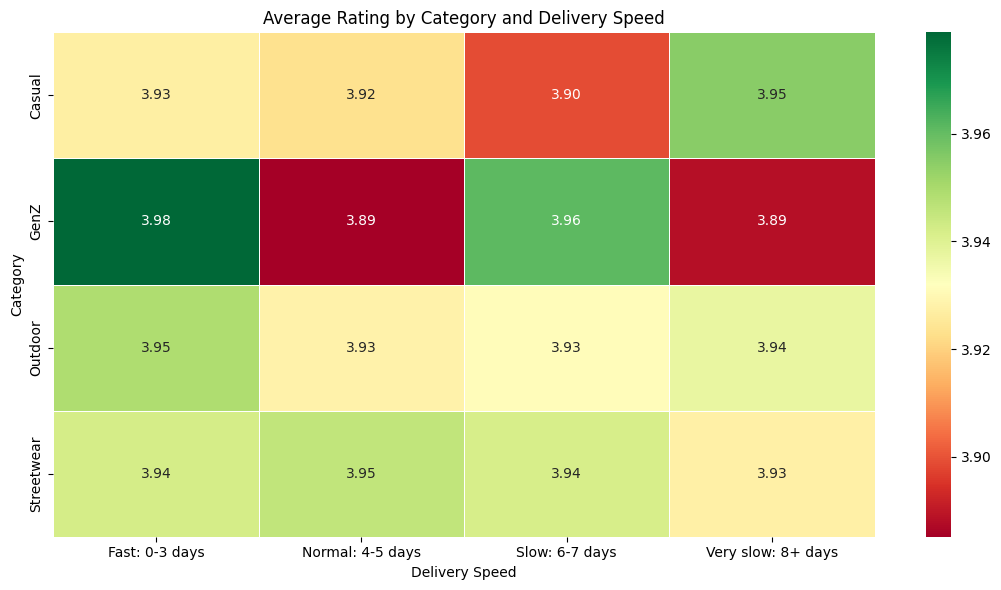

In [26]:
category_delivery = df_7.groupby(["category", "delivery_speed"], observed=True).agg(
    avg_rating=("rating", "mean"),
    low_rating_rate=("low_rating", "mean"),
    num_reviews=("review_id", "count")
).reset_index()

category_delivery = category_delivery[category_delivery["num_reviews"] >= 30]

heatmap_avg_rating = category_delivery.pivot(
    index="category",
    columns="delivery_speed",
    values="avg_rating"
)

plt.figure(figsize=(11, 6))

sns.heatmap(
    heatmap_avg_rating,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cmap="RdYlGn"
)

plt.title("Average Rating by Category and Delivery Speed")
plt.xlabel("Delivery Speed")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

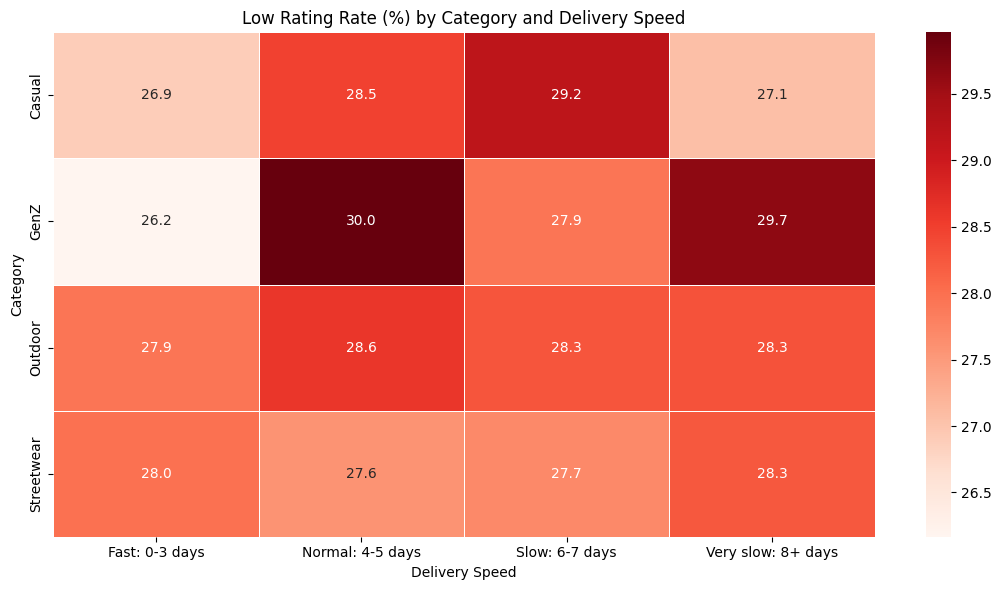

In [27]:
heatmap_low_rating = category_delivery.pivot(
    index="category",
    columns="delivery_speed",
    values="low_rating_rate"
) * 100

plt.figure(figsize=(11, 6))

sns.heatmap(
    heatmap_low_rating,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    cmap="Reds"
)

plt.title("Low Rating Rate (%) by Category and Delivery Speed")
plt.xlabel("Delivery Speed")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [28]:
price_rating = df_7.groupby("price_tier", observed=True).agg(
    avg_rating=("rating", "mean"),
    low_rating_rate=("low_rating", "mean"),
    num_reviews=("review_id", "count"),
    avg_delivery_days=("delivery_days", "mean")
).reset_index()

price_rating["low_rating_rate_pct"] = price_rating["low_rating_rate"] * 100

price_rating

,price_tier,avg_rating,low_rating_rate,num_reviews,avg_delivery_days,low_rating_rate_pct
0,Low price,3.933084,0.282873,28663,5.998744,28.287339
1,Mid-low price,3.936541,0.280114,28160,5.994247,28.011364
2,Mid-high price,3.942251,0.278971,28347,5.997778,27.897132
3,High price,3.932208,0.281139,28381,6.004122,28.113879


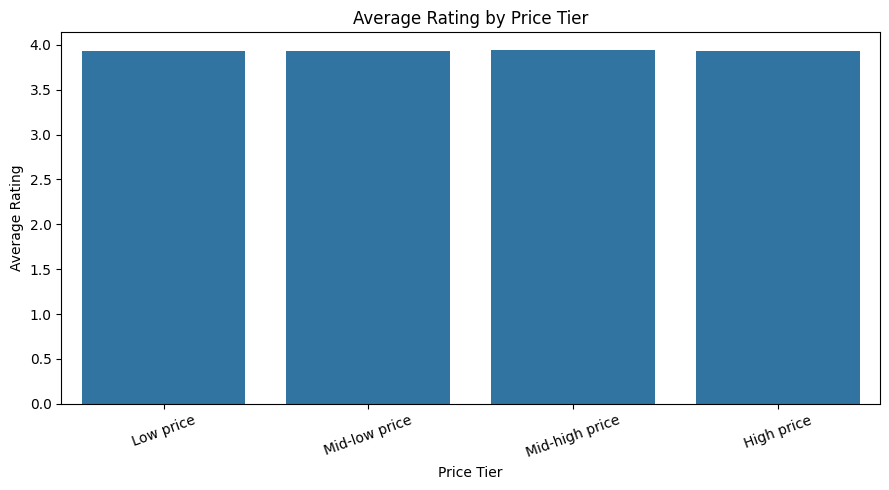

In [29]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=price_rating,
    x="price_tier",
    y="avg_rating"
)

plt.title("Average Rating by Price Tier")
plt.xlabel("Price Tier")
plt.ylabel("Average Rating")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

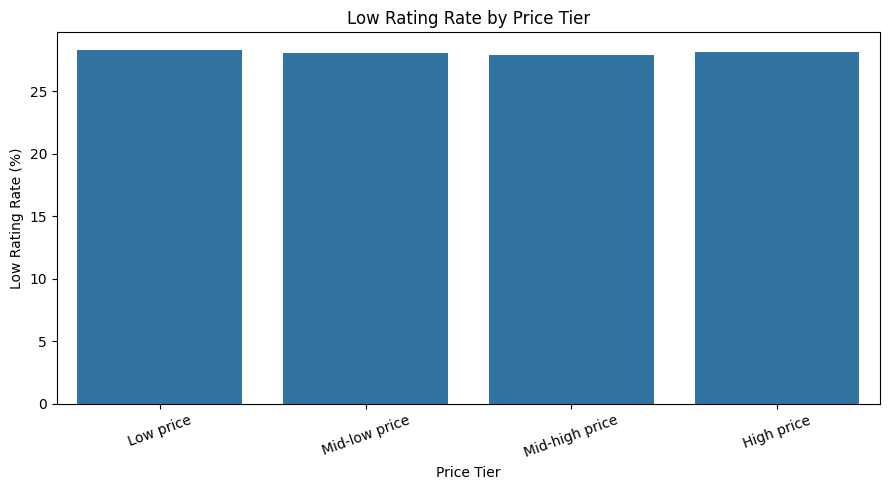

In [30]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=price_rating,
    x="price_tier",
    y="low_rating_rate_pct"
)

plt.title("Low Rating Rate by Price Tier")
plt.xlabel("Price Tier")
plt.ylabel("Low Rating Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [32]:
product_rating = df_7.groupby([
    "product_id", "product_name", "category", "segment"
]).agg(
    avg_rating=("rating", "mean"),
    low_rating_rate=("low_rating", "mean"),
    num_reviews=("review_id", "count"),
    avg_delivery_days=("delivery_days", "mean"),
    avg_price=("price", "mean")
).reset_index()

# Chỉ giữ sản phẩm có đủ review để đáng tin
product_rating = product_rating[product_rating["num_reviews"] >= 20].copy()

rating_threshold = product_rating["avg_rating"].quantile(0.25)
review_threshold = product_rating["num_reviews"].quantile(0.75)
delivery_threshold = product_rating["avg_delivery_days"].median()

def product_priority(row):
    if (row["avg_rating"] <= rating_threshold) and (row["num_reviews"] >= review_threshold):
        if row["avg_delivery_days"] >= delivery_threshold:
            return "Urgent: Low rating, high reviews, slow delivery"
        else:
            return "Product issue: Low rating, high reviews"
    elif row["avg_delivery_days"] >= delivery_threshold and row["avg_rating"] <= rating_threshold:
        return "Logistics issue: Low rating, slow delivery"
    else:
        return "Monitor"

product_rating["priority_group"] = product_rating.apply(product_priority, axis=1)

product_rating.head()

,product_id,product_name,category,segment,avg_rating,low_rating_rate,num_reviews,avg_delivery_days,avg_price,priority_group
0,3,DragonWear MA-03,Casual,All-weather,4.151515,0.181818,99,5.888889,10831.377188,Monitor
1,4,DragonWear MA-04,Casual,All-weather,3.857143,0.321429,28,5.785714,9610.756522,Monitor
3,8,DragonWear MA-08,Casual,All-weather,4.125000,0.222222,72,6.194444,5353.448368,Monitor
4,9,DragonWear MA-09,Casual,All-weather,3.857143,0.285714,63,5.904762,7077.195951,Monitor
10,17,DragonWear MA-17,Casual,All-weather,3.916667,0.291667,24,5.583333,4848.114706,Monitor


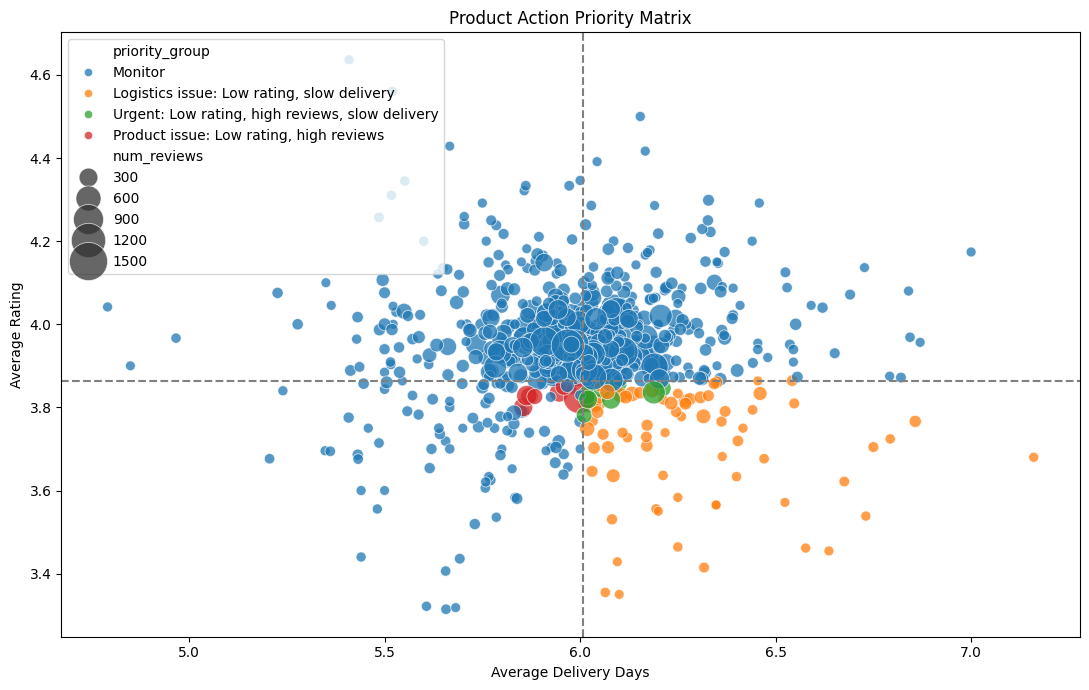

In [33]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=product_rating,
    x="avg_delivery_days",
    y="avg_rating",
    size="num_reviews",
    hue="priority_group",
    sizes=(50, 800),
    alpha=0.75
)

plt.axhline(rating_threshold, linestyle="--", color="gray")
plt.axvline(delivery_threshold, linestyle="--", color="gray")

plt.title("Product Action Priority Matrix")
plt.xlabel("Average Delivery Days")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.show()

In [34]:
priority_products = product_rating.sort_values(
    ["priority_group", "avg_rating", "num_reviews"],
    ascending=[True, True, False]
)

priority_products.head(20)

,product_id,product_name,category,segment,avg_rating,low_rating_rate,num_reviews,avg_delivery_days,avg_price,priority_group
805,1340,VietMode RP-32,Outdoor,Activewear,3.350000,0.500000,20,6.100000,2933.641534,"Logistics issue: Low rating, slow delivery"
1317,2202,VietMotion MA-16,Casual,All-weather,3.354839,0.419355,31,6.064516,3857.993548,"Logistics issue: Low rating, slow delivery"
1125,1875,BambooCraft UM-13,Streetwear,Balanced,3.414634,0.463415,41,6.317073,13973.850936,"Logistics issue: Low rating, slow delivery"
788,1308,VietMode MA-44,Casual,All-weather,3.428571,0.476190,21,6.095238,9126.562048,"Logistics issue: Low rating, slow delivery"
573,973,HanoiStreet UC-36,Streetwear,Everyday,3.454545,0.409091,22,6.636364,7486.731673,"Logistics issue: Low rating, slow delivery"
460,739,HanoiStreet RP-27,Outdoor,Activewear,3.461538,0.461538,26,6.576923,2078.146596,"Logistics issue: Low rating, slow delivery"
536,913,HanoiStreet UE-22,Streetwear,Performance,3.464286,0.357143,28,6.250000,4566.493506,"Logistics issue: Low rating, slow delivery"
811,1347,VietMode RP-39,Outdoor,Activewear,3.530612,0.367347,49,6.081633,3892.450866,"Logistics issue: Low rating, slow delivery"
1107,1851,SaigonCore YY-46,GenZ,Trendy,3.538462,0.423077,26,6.730769,3909.230724,"Logistics issue: Low rating, slow delivery"
1077,1817,SaigonCore YY-12,GenZ,Trendy,3.550000,0.550000,20,6.200000,2735.535138,"Logistics issue: Low rating, slow delivery"


In [35]:
overall_avg_rating = df_7["rating"].mean()
overall_low_rating_rate = df_7["low_rating"].mean() * 100

worst_category = category_rating.sort_values("avg_rating").iloc[0]
highest_low_category = category_rating.sort_values("low_rating_rate", ascending=False).iloc[0]

worst_segment = segment_rating.sort_values("avg_rating").iloc[0]

worst_delivery_speed = delivery_speed_perf.sort_values("avg_rating").iloc[0]
highest_low_delivery_speed = delivery_speed_perf.sort_values("low_rating_rate", ascending=False).iloc[0]

top_priority_product = product_rating[
    product_rating["priority_group"] != "Monitor"
].sort_values(["avg_rating", "num_reviews"], ascending=[True, False]).head(1)

print("OVERALL SATISFACTION")
print(f"- Average rating: {overall_avg_rating:.2f}/5")
print(f"- Low rating rate (≤3 stars): {overall_low_rating_rate:.2f}%")

print("\nDELIVERY IMPACT")
print(f"- Worst delivery speed group: {worst_delivery_speed['delivery_speed']} with average rating {worst_delivery_speed['avg_rating']:.2f}")
print(f"- Highest low-rating delivery group: {highest_low_delivery_speed['delivery_speed']} with low rating rate {highest_low_delivery_speed['low_rating_rate']*100:.2f}%")

print("\nCATEGORY IMPACT")
print(f"- Worst category by average rating: {worst_category['category']} with average rating {worst_category['avg_rating']:.2f}")
print(f"- Highest low-rating category: {highest_low_category['category']} with low rating rate {highest_low_category['low_rating_rate']*100:.2f}%")

print("\nSEGMENT IMPACT")
print(f"- Worst segment by average rating: {worst_segment['segment']} with average rating {worst_segment['avg_rating']:.2f}")

print("\nPRIORITY PRODUCT")
if len(top_priority_product) > 0:
    p = top_priority_product.iloc[0]
    print(f"- Product to prioritize: {p['product_name']} | avg rating {p['avg_rating']:.2f}, reviews {p['num_reviews']}, avg delivery {p['avg_delivery_days']:.2f} days")
else:
    print("- No urgent product found under current thresholds.")

OVERALL SATISFACTION
- Average rating: 3.94/5
- Low rating rate (≤3 stars): 28.08%

DELIVERY IMPACT
- Worst delivery speed group: Very slow: 8+ days with average rating 3.93
- Highest low-rating delivery group: Very slow: 8+ days with low rating rate 28.31%

CATEGORY IMPACT
- Worst category by average rating: GenZ with average rating 3.92
- Highest low-rating category: GenZ with low rating rate 28.75%

SEGMENT IMPACT
- Worst segment by average rating: Trendy with average rating 3.92

PRIORITY PRODUCT
- Product to prioritize: VietMode RP-32 | avg rating 3.35, reviews 20, avg delivery 6.10 days
